In [1]:
import os, glob
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import cv2

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
# CONSTANTS!!!

# STEP 1 - Load and visualize data
dataInputPath = '/kaggle/input/childrens-dental-panoramic-radiographs-dataset/Dental_dataset/Adult tooth segmentation dataset/Dataset and code'
imagePathInputTrain = os.path.join(dataInputPath, 'train/images/')
maskPathInputTrain = os.path.join(dataInputPath, 'train/masks/')

imagePathInputTest = os.path.join(dataInputPath, 'test/images/')
maskPathInputTest = os.path.join(dataInputPath, 'test/masks/')


dataOutputPath = 'data/slices/'
imageSliceOutput = os.path.join(dataOutputPath, 'img/')
maskSliceOutput = os.path.join(dataOutputPath, 'mask/')

# STEP 2 - Image normalization
HOUNSFIELD_MIN = -1000
HOUNSFIELD_MAX = 2000
HOUNSFIELD_RANGE = HOUNSFIELD_MAX - HOUNSFIELD_MIN

# STEP 3 - Slicing and saving
SLICE_X = True
SLICE_Y = True
SLICE_Z = False

SLICE_DECIMATE_IDENTIFIER = 3

In [24]:
# Load image and see max min Hounsfield units
# imgPath = os.path.join(imagePathInput, 'tooth1.nii')
imgPath = os.path.join(imagePathInputTrain, 'cate1-00001.jpg')
img = cv2.imread(imgPath, cv2.IMREAD_UNCHANGED)
# img = nib.load(imgPath).get_fdata()
np.min(img), np.max(img), img.shape, type(img)

(0, 255, (1127, 1991, 3), numpy.ndarray)

In [23]:
# Load image mask and see max min Hounsfield units
# maskPath = os.path.join(maskPathInput, 'tooth1.nii')
maskPath = os.path.join(maskPathInputTrain, 'cate1-00001.bmp')
# mask = nib.load(maskPath).get_fdata()
mask= cv2.imread(maskPath, cv2.IMREAD_UNCHANGED)
np.min(mask), np.max(mask), mask.shape, type(mask)

(0, 255, (1127, 1991), numpy.ndarray)

1


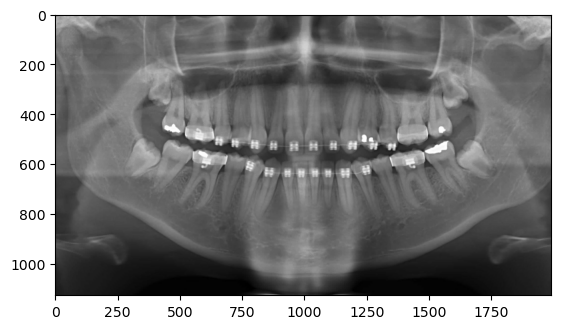

2


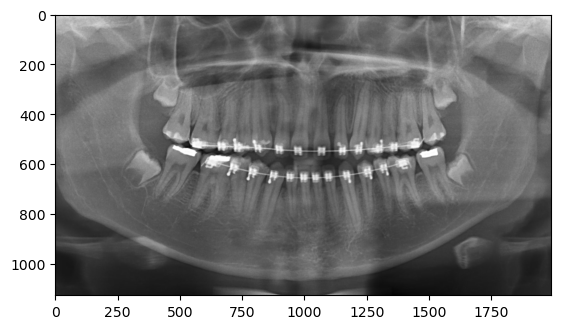

3


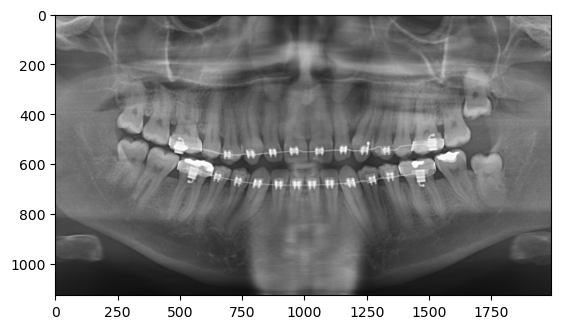

4


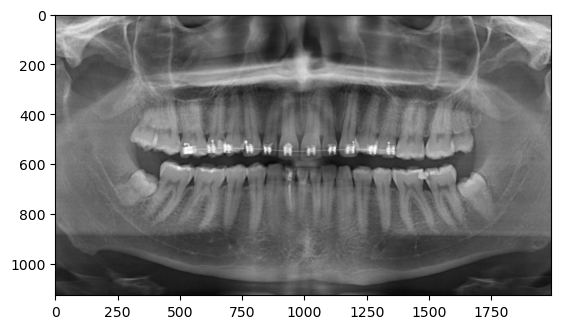

5


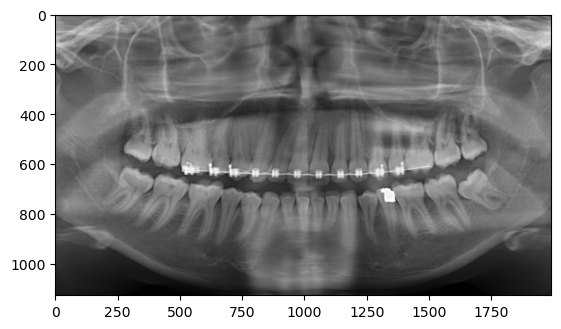

6


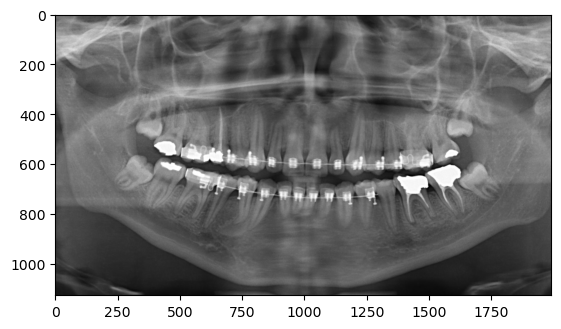

7


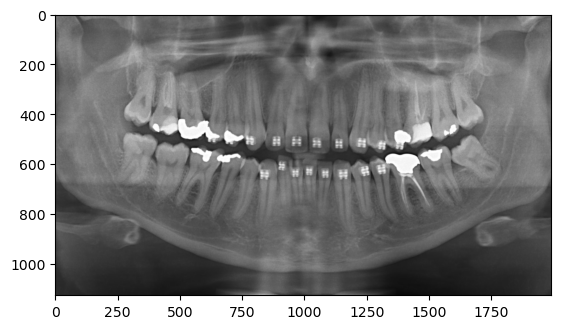

8


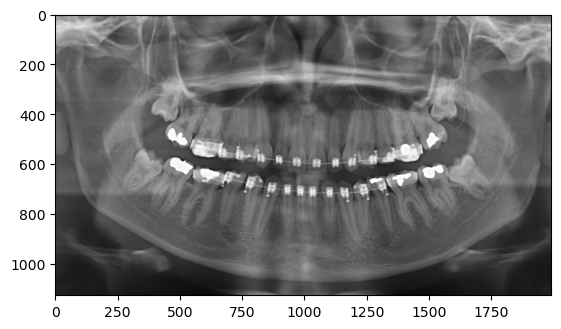

9


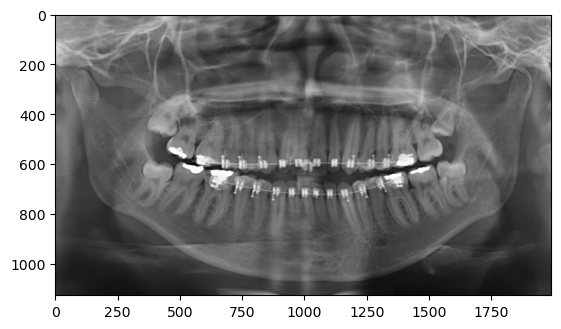

In [34]:
for i in range(1, 10):
    print(i)
    # Show image slice
    imgPath = os.path.join(imagePathInputTrain, f'cate1-0000{i}.jpg')
    img = cv2.imread(imgPath, cv2.IMREAD_UNCHANGED)
    # imgSlice = mask[20,:,:]
    plt.imshow(img)
    plt.show()

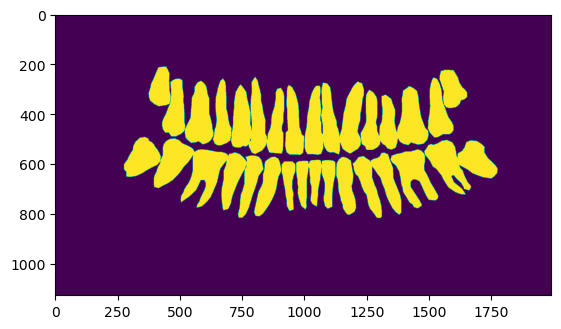

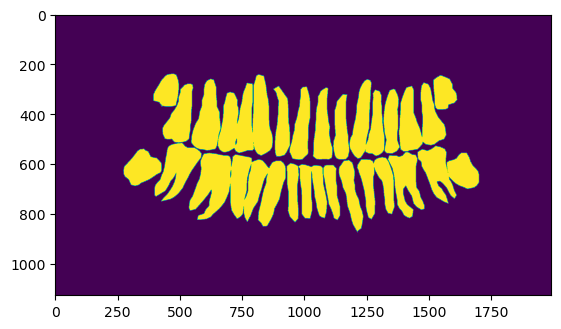

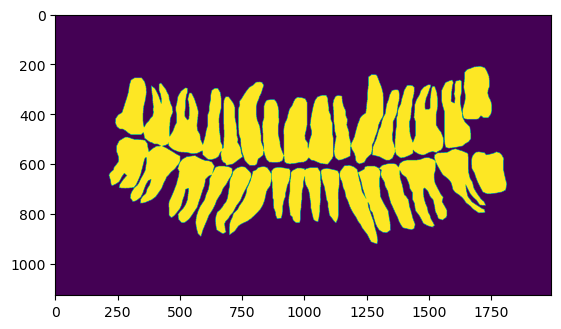

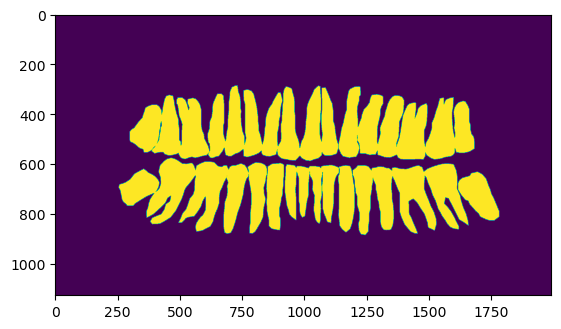

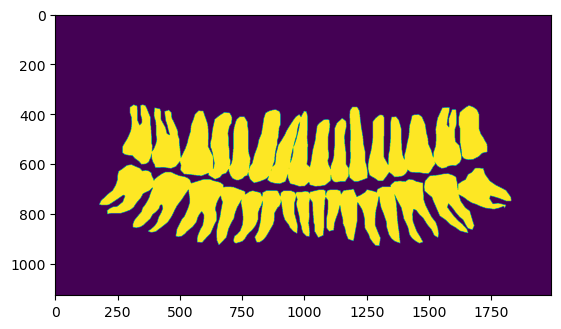

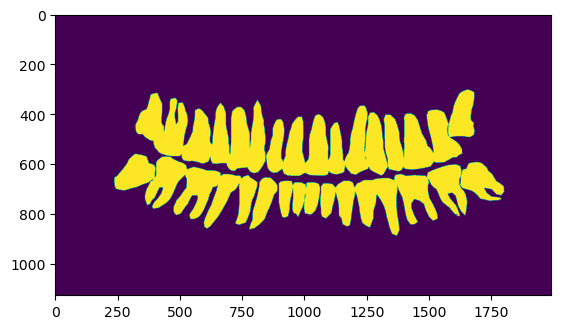

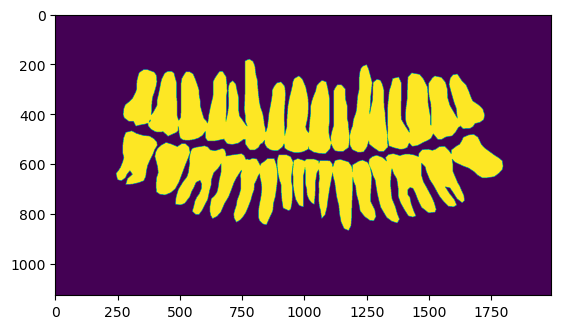

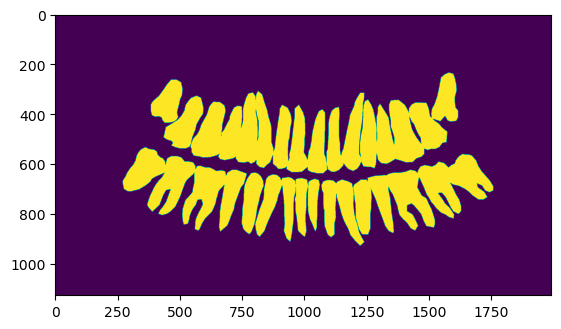

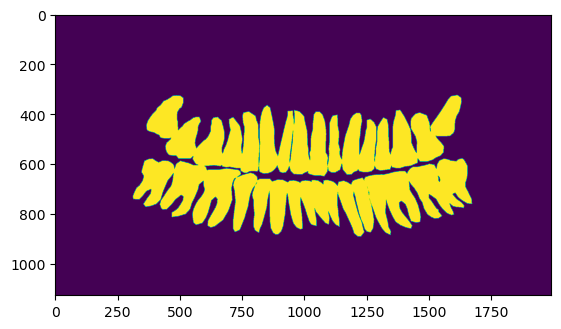

In [35]:
for i in range(1, 10):
    # Show image slice
    maskPath = os.path.join(maskPathInputTrain, f'cate1-0000{i}.bmp')
    # mask = nib.load(maskPath).get_fdata()
    mask= cv2.imread(maskPath, cv2.IMREAD_UNCHANGED)
    # imgSlice = mask[20,:,:]
    plt.imshow(mask)
    plt.show()

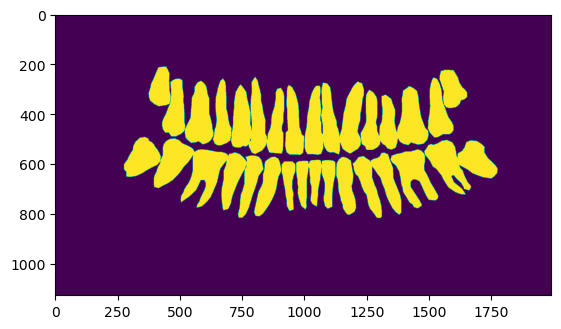

In [28]:
plt.imshow(mask)
plt.show()

In [27]:
# Normalize image
def normalizeImageIntensityRange(img):
    img[img < HOUNSFIELD_MIN] = HOUNSFIELD_MIN
    img[img > HOUNSFIELD_MAX] = HOUNSFIELD_MAX
    return (img - HOUNSFIELD_MIN) / HOUNSFIELD_RANGE

nImg = normalizeImageIntensityRange(img)
np.min(nImg), np.max(nImg), nImg.shape, type(nImg)

(0.3333333333333333, 0.41833333333333333, (1127, 1991, 3), numpy.ndarray)

# Below Code is for 3d Volume only, which slice 3d volume at each dimension i.e x, y, z and save each slice separately converting into 2d image.
# It will not work for my data since our data is 2d images not 3d volume.

In [8]:
# Read image or mask volume
def readImageVolume(imgPath, normalize=False):
    img = nib.load(imgPath).get_fdata()
    if normalize:
        return normalizeImageIntensityRange(img)
    else:
        return img
    
readImageVolume(imgPath, normalize=True)
readImageVolume(maskPath, normalize=False)

memmap([[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        ...,

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
    

In [9]:
# Save volume slice to file
def saveSlice(img, fname, path):
    img = np.uint8(img * 255)
    fout = os.path.join(path, f'{fname}.png')
    cv2.imwrite(fout, img)
    print(f'[+] Slice saved: {fout}', end='\r')
    
saveSlice(nImg[20,:,:], 'test', imageSliceOutput)
saveSlice(mask[20,:,:], 'test', maskSliceOutput)

[+] Slice saved: data/slices/img/test.png


In [10]:
# Slice image in all directions and save
def sliceAndSaveVolumeImage(vol, fname, path):
    (dimx, dimy, dimz) = vol.shape
    print(dimx, dimy, dimz)
    cnt = 0
    if SLICE_X:
        cnt += dimx
        print('Slicing X: ')
        for i in range(dimx):
            saveSlice(vol[i,:,:], fname+f'-slice{str(i).zfill(SLICE_DECIMATE_IDENTIFIER)}_x', path)
            
    if SLICE_Y:
        cnt += dimy
        print('Slicing Y: ')
        for i in range(dimy):
            saveSlice(vol[:,i,:], fname+f'-slice{str(i).zfill(SLICE_DECIMATE_IDENTIFIER)}_y', path)
            
    if SLICE_Z:
        cnt += dimz
        print('Slicing Z: ')
        for i in range(dimz):
            saveSlice(vol[:,:,i], fname+f'-slice{str(i).zfill(SLICE_DECIMATE_IDENTIFIER)}_z', path)
    return cnt

In [11]:
# Read and process image volumes
for index, filename in enumerate(sorted(glob.iglob(imagePathInput+'*.nii'))):
    img = readImageVolume(filename, True)
    print(filename, img.shape, np.sum(img.shape), np.min(img), np.max(img))
    numOfSlices = sliceAndSaveVolumeImage(img, 'tooth'+str(index), imageSliceOutput)
    print(f'\n{filename}, {numOfSlices} slices created \n')

data/volumes/img/tooth1.nii (45, 45, 90) 180 0.022333333333333334 1.0

Slicing X: 

[+] Slice saved: data/slices/img/tooth0-slice000_x.png
[+] Slice saved: data/slices/img/tooth0-slice001_x.png
[+] Slice saved: data/slices/img/tooth0-slice002_x.png
[+] Slice saved: data/slices/img/tooth0-slice003_x.png
[+] Slice saved: data/slices/img/tooth0-slice004_x.png
[+] Slice saved: data/slices/img/tooth0-slice005_x.png
[+] Slice saved: data/slices/img/tooth0-slice006_x.png
[+] Slice saved: data/slices/img/tooth0-slice007_x.png
[+] Slice saved: data/slices/img/tooth0-slice008_x.png
[+] Slice saved: data/slices/img/tooth0-slice009_x.png
[+] Slice saved: data/slices/img/tooth0-slice010_x.png
[+] Slice saved: data/slices/img/tooth0-slice011_x.png
[+] Slice saved: data/slices/img/tooth0-slice012_x.png
[+] Slice saved: data/slices/img/tooth0-slice013_x.png
[+] Slice saved: data/slices/img/tooth0-slice014_x.png
[+] Slice saved: data/slices/img/tooth0-slice015_x.png
[+] Slice saved: data/slices/img/too

In [12]:
# Read and process image mask volumes
for index, filename in enumerate(sorted(glob.iglob(maskPathInput+'*.nii'))):
    img = readImageVolume(filename, False)
    print(filename, img.shape, np.sum(img.shape), np.min(img), np.max(img))
    numOfSlices = sliceAndSaveVolumeImage(img, 'tooth'+str(index), maskSliceOutput)
    print(f'\n{filename}, {numOfSlices} slices created \n')

data/volumes/mask/tooth1.nii (45, 45, 90) 180 0.0 1.0

Slicing X: 

Slicing Y: aved: data/slices/mask/tooth0-slice044_x.png

[+] Slice saved: data/slices/mask/tooth0-slice044_y.png

data/volumes/mask/tooth1.nii, 90 slices created 



data/volumes/mask/tooth2.nii (45, 45, 90) 180 0.0 1.0

Slicing X: 

Slicing Y: aved: data/slices/mask/tooth1-slice044_x.png

[+] Slice saved: data/slices/mask/tooth1-slice044_y.png

data/volumes/mask/tooth2.nii, 90 slices created 



data/volumes/mask/tooth3.nii (46, 46, 92) 184 0.0 1.0

Slicing X: 

Slicing Y: aved: data/slices/mask/tooth2-slice045_x.png

[+] Slice saved: data/slices/mask/tooth2-slice045_y.png

data/volumes/mask/tooth3.nii, 92 slices created 



data/volumes/mask/tooth4.nii (44, 44, 88) 176 0.0 1.0

Slicing X: 

Slicing Y: aved: data/slices/mask/tooth3-slice043_x.png

[+] Slice saved: data/slices/mask/tooth3-slice043_y.png

data/volumes/mask/tooth4.nii, 88 slices created 



data/volumes/mask/tooth5.nii (50, 50, 100) 200 0.0 1.0

Slicing 